# Free Spoken Digit Dataset

**Metody ekstrakcji cech:**
1. Spektralna: MFCC (Mel-frequency cepstral coefficients).
2. Ręczna ekstrakcja cech (Zero Crossing Rate, Spectral Rolloff, etc.).

**Modele:** SVM, Las Losowy (Random Forest), KNN.

In [33]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


## Ładowanie danych
Pobieranie zbioru danych i ładowanie plików audio.
Parsujemy nazwę pliku, aby wyodrębnić etykietę.

In [34]:
path = kagglehub.dataset_download("joserzapata/free-spoken-digit-dataset-fsdd")
recordings_path = os.path.join(path, "recordings")

files = glob.glob(os.path.join(recordings_path, "*.wav"))

data = []
labels = []
max_len = 0

for f in files:
    filename = os.path.basename(f)
    digit = int(filename.split('_')[0])
    
    y, sr = librosa.load(f, sr=None)
    
    data.append(y)
    labels.append(digit)
    
    if len(y) > max_len:
        max_len = len(y)

print(f"Loaded {len(data)} files.")
print(f"Max audio length: {max_len} samples.")

Loaded 3000 files.
Max audio length: 18262 samples.


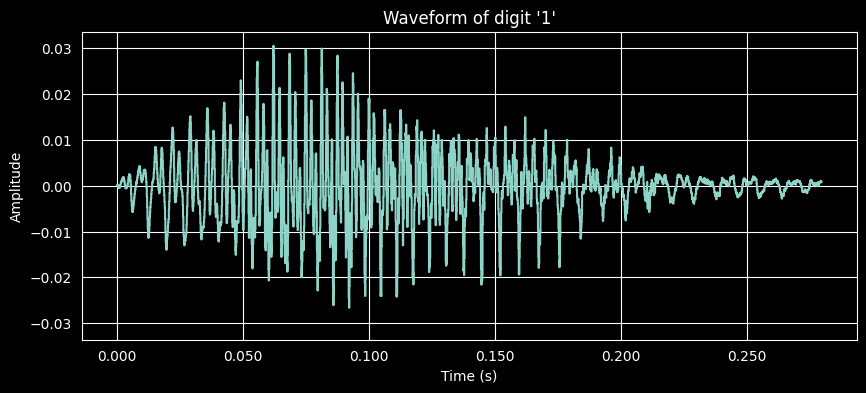

In [35]:
plt.figure(figsize=(10, 4))
librosa.display.waveshow(data[0], sr=8000)
plt.title(f"Waveform of digit '{labels[0]}'")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

In [36]:
from IPython.display import Audio, display

display(Audio(data[0], rate=8000))

## Metoda ekstrakcji cech 1: MFCC

In [37]:
def extract_features_mfcc(audio_data, sr=8000, n_mfcc=13):
    features = []
    for y in audio_data:
        n_fft = 2048
        if len(y) < n_fft:
            y = librosa.util.fix_length(y, size=n_fft)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft)

        mean = np.mean(mfcc, axis=1)
        std = np.std(mfcc, axis=1)
        feature_vector = np.concatenate((mean, std))
        features.append(feature_vector)
    return np.array(features)

In [38]:
X_mfcc = extract_features_mfcc(data)
y_labels = np.array(labels)
print(f"MFCC Feature shape: {X_mfcc.shape}")

MFCC Feature shape: (3000, 26)


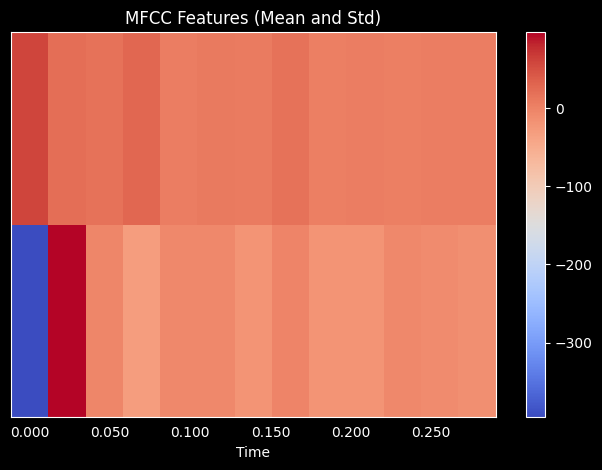

In [39]:
librosa.display.specshow(X_mfcc[0].reshape(2, -1), x_axis='time')
plt.colorbar()
plt.title('MFCC Features (Mean and Std)')
plt.tight_layout()
plt.show()

## Metoda ekstrakcji cech 2: Ręczna ekstrakcja

In [44]:
def manual_features(signal, rate=8000, n_fft=2048):
    y = signal
    if len(y) < n_fft:
        y = librosa.util.fix_length(y, size=n_fft)

    hop_length = max(256, n_fft // 4)

    zcr = librosa.feature.zero_crossing_rate(y=y, hop_length=hop_length)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=rate, n_fft=n_fft, hop_length=hop_length)
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=rate, n_fft=n_fft, hop_length=hop_length)
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=rate, n_fft=n_fft, hop_length=hop_length)
    spec_cont = librosa.feature.spectral_contrast(y=y, sr=rate, n_fft=n_fft, hop_length=hop_length, n_bands=4)
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=rate, n_fft=n_fft, hop_length=hop_length)
    rmse = librosa.feature.rms(y=y, frame_length=n_fft, hop_length=hop_length)

    return np.concatenate((
        zcr.mean(axis=1),
        rolloff.mean(axis=1),
        spec_cent.mean(axis=1),
        spec_bw.mean(axis=1),
        spec_cont.mean(axis=1),
        chroma_stft.mean(axis=1),
        rmse.mean(axis=1)
    ))

In [45]:
X_manual = np.array([manual_features(y, rate=8000) for y in data])
print(f"Manual feature shape: {X_manual.shape}")
pd.DataFrame(X_manual).describe()

/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Manual feature shape: (3000, 22)


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.163221,2250.163343,1167.202689,966.633748,29.139386,18.899925,19.694146,17.529211,21.100417,0.317355,...,0.342328,0.370495,0.353744,0.337700,0.330117,0.359388,0.412960,0.449889,0.381021,0.039839
std,0.069416,576.315649,291.343862,159.479387,6.202872,4.155811,3.544965,2.830496,3.845933,0.195645,...,0.198074,0.206325,0.202196,0.198059,0.188232,0.182573,0.194508,0.203973,0.193308,0.027748
min,0.041406,863.281250,585.492046,396.452806,14.932829,9.269678,11.967976,9.128485,13.679153,0.008789,...,0.006014,0.006800,0.008845,0.012554,0.019025,0.015025,0.012113,0.010971,0.012964,0.001314
25%,0.112887,1829.124814,965.387180,856.824639,24.651741,15.440815,17.162877,15.365015,18.578318,0.154375,...,0.176606,0.200899,0.186364,0.167613,0.176150,0.214444,0.272866,0.302707,0.235668,0.011144
50%,0.147819,2265.625000,1111.491006,973.121463,27.687486,18.952558,19.291513,17.020645,20.578060,0.298578,...,0.318127,0.347022,0.328702,0.316491,0.307117,0.354577,0.406721,0.435740,0.365975,0.040503
75%,0.196309,2704.352679,1348.052035,1093.452118,33.265599,22.140534,21.974548,19.488738,23.013563,0.445719,...,0.483587,0.520488,0.498846,0.481850,0.460404,0.486299,0.548242,0.587719,0.506205,0.058241
max,0.451477,3475.260417,2226.571305,1369.924617,48.221590,31.880878,32.435038,29.263194,32.469208,1.000000,...,1.000000,1.000000,1.000000,0.981630,1.000000,0.998716,1.000000,1.000000,1.000000,0.145232


## Trenowanie modeli i porównanie
Dzielimy oba zestawy danych (MFCC i Ręczna ekstakcja) na zbiory treningowe i testowe (80/20).
Następnie trenujemy trzy standardowe klasyfikatory (SVM, Random Forest, KNN) na obu zestawach cech i porównujemy ich dokładność.

In [46]:
def train_and_evaluate(X, y, name_prefix):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    models = {
        "SVM": SVC(),
        "RandomForest": RandomForestClassifier(random_state=42),
        "KNN": KNeighborsClassifier()
    }
    
    results = {}
    
    print(f"--- Results for {name_prefix} ---")
    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        results[name] = acc
        print(f"{name} Accuracy: {acc:.4f}")
    print("\n")
    return results

results_mfcc = train_and_evaluate(X_mfcc, y_labels, "MFCC Features")


results_manual = train_and_evaluate(X_manual, y_labels, "Manual Features")

--- Results for MFCC Features ---
SVM Accuracy: 0.9850
RandomForest Accuracy: 0.9567
KNN Accuracy: 0.9717


--- Results for Manual Features ---
SVM Accuracy: 0.8200
RandomForest Accuracy: 0.8217
KNN Accuracy: 0.7750




## Optymalizacja
Wybieramy najlepiej działającą kombinację (SVM z MFCC) i optymalizujemy jej hiperparametry za pomocą `GridSearchCV`.

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X_mfcc, y_labels, test_size=0.2, random_state=42, stratify=y_labels)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, verbose=1, n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print(f"Best Parameters: {grid.best_params_}")
print(f"Best Cross-Validation Score: {grid.best_score_:.4f}")

best_model = grid.best_estimator_
y_pred_opt = best_model.predict(X_test_scaled)
print(f"Test Set Accuracy (Optimized): {accuracy_score(y_test, y_pred_opt):.4f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation Score: 0.9850
Test Set Accuracy (Optimized): 0.9833


## Wizualizacja wyników

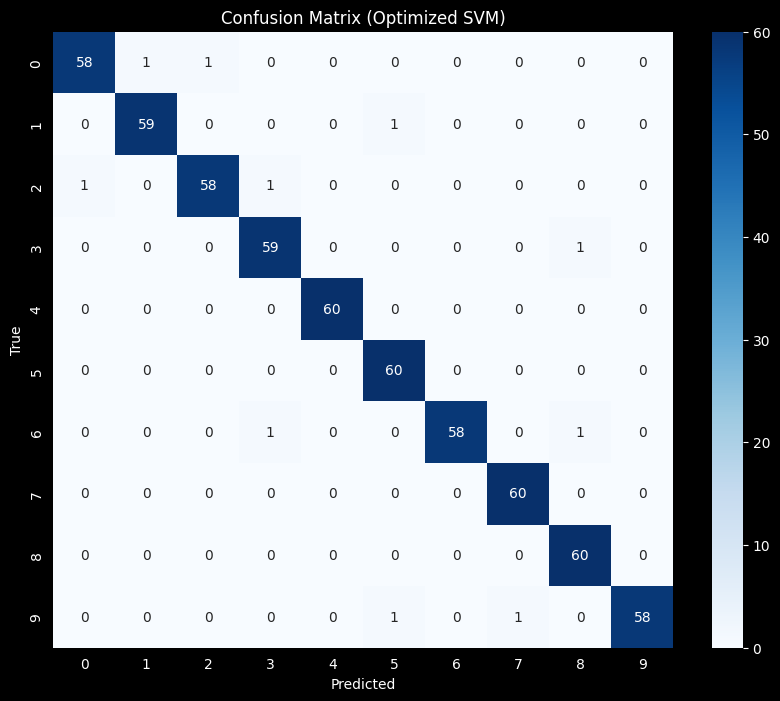

In [48]:
cm = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Optimized SVM)')
plt.show()